In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
# Staionarity tests
from statsmodels.tsa.stattools import adfuller, kpss
# ACF and PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# ARIMA
from statsmodels.tsa.arima.model import ARIMA


In [ ]:
# # 1. Load dataset
# df = pd.read_csv("../data/chaos_rising_combined_clean.csv")

# # 2. Parse timestamp
# df["cm_updated"] = pd.to_datetime(df["cm_updated"])

# # 3. Reduce timestamp to daily snapshots
# df["snapshot_date"] = df["cm_updated"].dt.date

# # 4. Define the price contribution per card
# df["set_price_component"] = (
#     df["cm_avg1"].fillna(0) +
#     df["cm_avg1_holo"].fillna(0)
# )

# # 5. Aggregate: total set cost per day
# set_ts = (
#     df.groupby("snapshot_date")["set_price_component"]
#       .sum()
#       .sort_index()
# )

# # 6. Plot the total set cost time series
# plt.figure(figsize=(12, 5))
# plt.plot(set_ts.index, set_ts.values, marker="o")
# plt.title("Chaos Rising – Total Set Cost Over Time")
# plt.xlabel("Date")
# plt.ylabel("Total Set Cost (USD)")
# plt.grid(True)
# plt.tight_layout()
# plt.show()



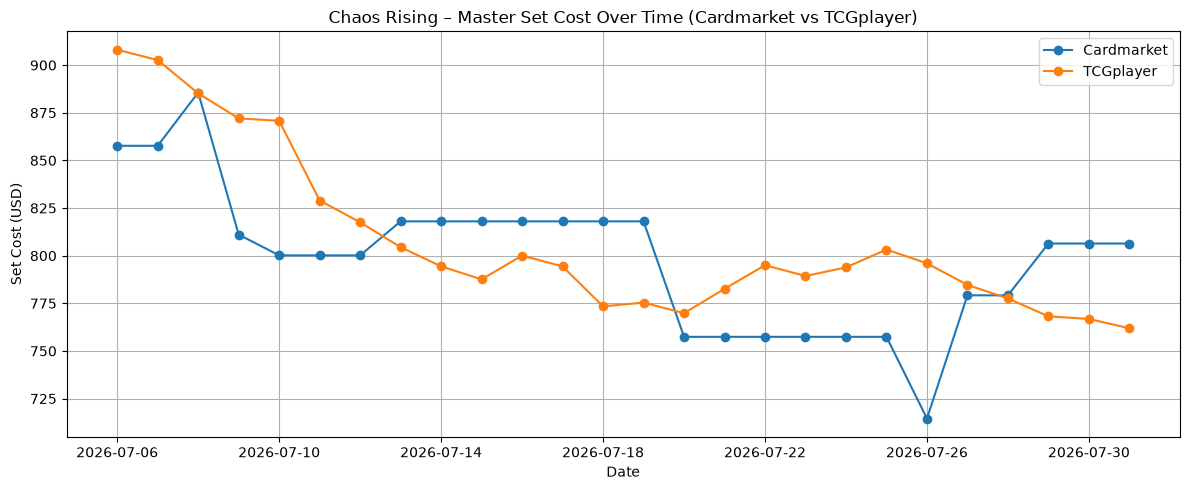

In [2]:
# Loading dataset
df = pd.read_csv("../data/chaos_rising_combined_clean.csv")

# Cardmarket price contribution per card
df["cm_price_component"] = (
    df["cm_avg1"].fillna(0) +
    df["cm_avg1_holo"].fillna(0)
)

# TCGplayer price contribution per card
df["tp_price_component"] = (
    df["tp_normal_marketPrice"].fillna(0) +
    df["tp_holofoil_marketPrice"].fillna(0) +
    df["tp_reverse_holofoil_marketPrice"].fillna(0)
)

# total set cost per day
cm_set_ts = (
    df.groupby("snapshot_date")["cm_price_component"]
      .sum()
      .sort_index()
)

tp_set_ts = (
    df.groupby("snapshot_date")["tp_price_component"]
      .sum()
      .sort_index()
)

# Plot both time series together
plt.figure(figsize=(12, 5))
plt.plot(cm_set_ts.index, cm_set_ts.values, marker="o", label="Cardmarket")
plt.plot(tp_set_ts.index, tp_set_ts.values, marker="o", label="TCGplayer")

plt.title("Chaos Rising – Master Set Cost Over Time (Cardmarket vs TCGplayer)")
plt.xlabel("Date")
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=8))
plt.ylabel("Set Cost (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
def plot_set_and_rarity_trends(csv_path, source="tp", period=3):
    """
    Plot total set price trend (full-width) and rarity-level trends (4x2 grid)
    using either Cardmarket ("cm") or TCGplayer ("tp") pricing.

    Parameters
    ----------
    csv_path : str
        Path to the cleaned combined CSV file.
    source : str
        "cm" for Cardmarket prices, "tp" for TCGplayer prices.
    period : int
        Seasonal decomposition period (controls trend smoothing).
        Example: 3 (light smoothing), 7 (weekly), 14 (biweekly), 30 (monthly).
    """

    # --- Load dataset --- #
    df = pd.read_csv(csv_path)

    # Ensure snapshot_date is a proper datetime index (messes with the dates in the plot otherwise)
    df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])

    # Count printings per rarity by collapsing to unique cards first
    card_printings = (
        df.groupby(["rarity", "id"])
        .agg({
            "cm_avg1": "max",
            "cm_avg1_holo": "max"
        })
    )

    # Count printings per card
    card_printings["n_printings"] = (
        card_printings["cm_avg1"].notna().astype(int) +
        card_printings["cm_avg1_holo"].notna().astype(int)
    )

    # Sum printings per rarity
    rarity_counts = (
        card_printings.groupby("rarity")["n_printings"]
                    .sum()
                    .to_dict()
    )

    # --- Select price source --- #
    if source == "cm":
        df["set_price_component"] = (
            df["cm_avg1"].fillna(0) +
            df["cm_avg1_holo"].fillna(0)
        )
        title_prefix = "Cardmarket"
    elif source == "tp":
        df["set_price_component"] = (
            df["tp_normal_marketPrice"].fillna(0) +
            df["tp_holofoil_marketPrice"].fillna(0) +
            df["tp_reverse_holofoil_marketPrice"].fillna(0)
        )
        title_prefix = "TCGplayer"
    else:
        raise ValueError("source must be 'cm' or 'tp'")

    # --- Total set cost per day --- #
    set_ts = (
        df.groupby("snapshot_date")["set_price_component"]
          .sum()
          .sort_index()
    )

    # --- Decompose total set price --- #
    decomp = seasonal_decompose(set_ts, model="additive", period=period)

    # --- Rarity-level time series --- #
    rarity_ts = (
        df.groupby(["snapshot_date", "rarity"])["set_price_component"]
          .sum()
          .unstack(fill_value=0)
          .sort_index()
    )

    # --- Rarity trends --- #
    rarity_trends = {}
    for rarity in rarity_ts.columns:
        series = rarity_ts[rarity]
        if series.sum() == 0:
            continue
        decomp_r = seasonal_decompose(series, model="additive", period=period)
        rarity_trends[rarity] = decomp_r.trend

    # --- Economic importance --- #
    importance = {r: trend.sum() for r, trend in rarity_trends.items()}
    total_importance = sum(importance.values())
    importance_pct = {r: (importance[r] / total_importance) * 100
                      for r in importance}

    # --- Sort rarities by importance --- #
    rarities = sorted(
        rarity_trends.keys(),
        key=lambda r: importance[r],
        reverse=True
    )

    # --- Plot layout --- #
    rows, cols = 5, 2
    plt.figure(figsize=(16, 22))

    # --- Row 1: Total set trend (full width) --- #
    ax_total = plt.subplot(rows, 1, 1)
    ax_total.plot(decomp.trend.index, decomp.trend.values,
                  linewidth=3, color="orange")
    ax_total.set_title(f"Master Set Price Trend ({title_prefix})", fontsize=16)
    ax_total.set_xlabel("Date")
    ax_total.set_ylabel("Set Cost (USD)")
    ax_total.grid(True)
    ax_total.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=10))

    # --- Rarity trends --- #
    start_index = 3  # first rarity subplot index

    for i, rarity in enumerate(rarities):
        trend = rarity_trends[rarity]
        
        ax = plt.subplot(rows, cols, start_index + i)
        ax.plot(trend.index, trend.values, linewidth=2)

        pct = importance_pct[rarity]
        count = rarity_counts.get(rarity, 0)

        ax.set_title(
            f"{rarity} trend (n={count})\nImportance: {pct:.2f}%",
            fontsize=12
        )

        # Month-day formatting
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())

        ax.set_xlabel("Month-Day")
        ax.set_ylabel("Contribution (USD)")
        ax.grid(True)

    plt.tight_layout()
    plt.show()


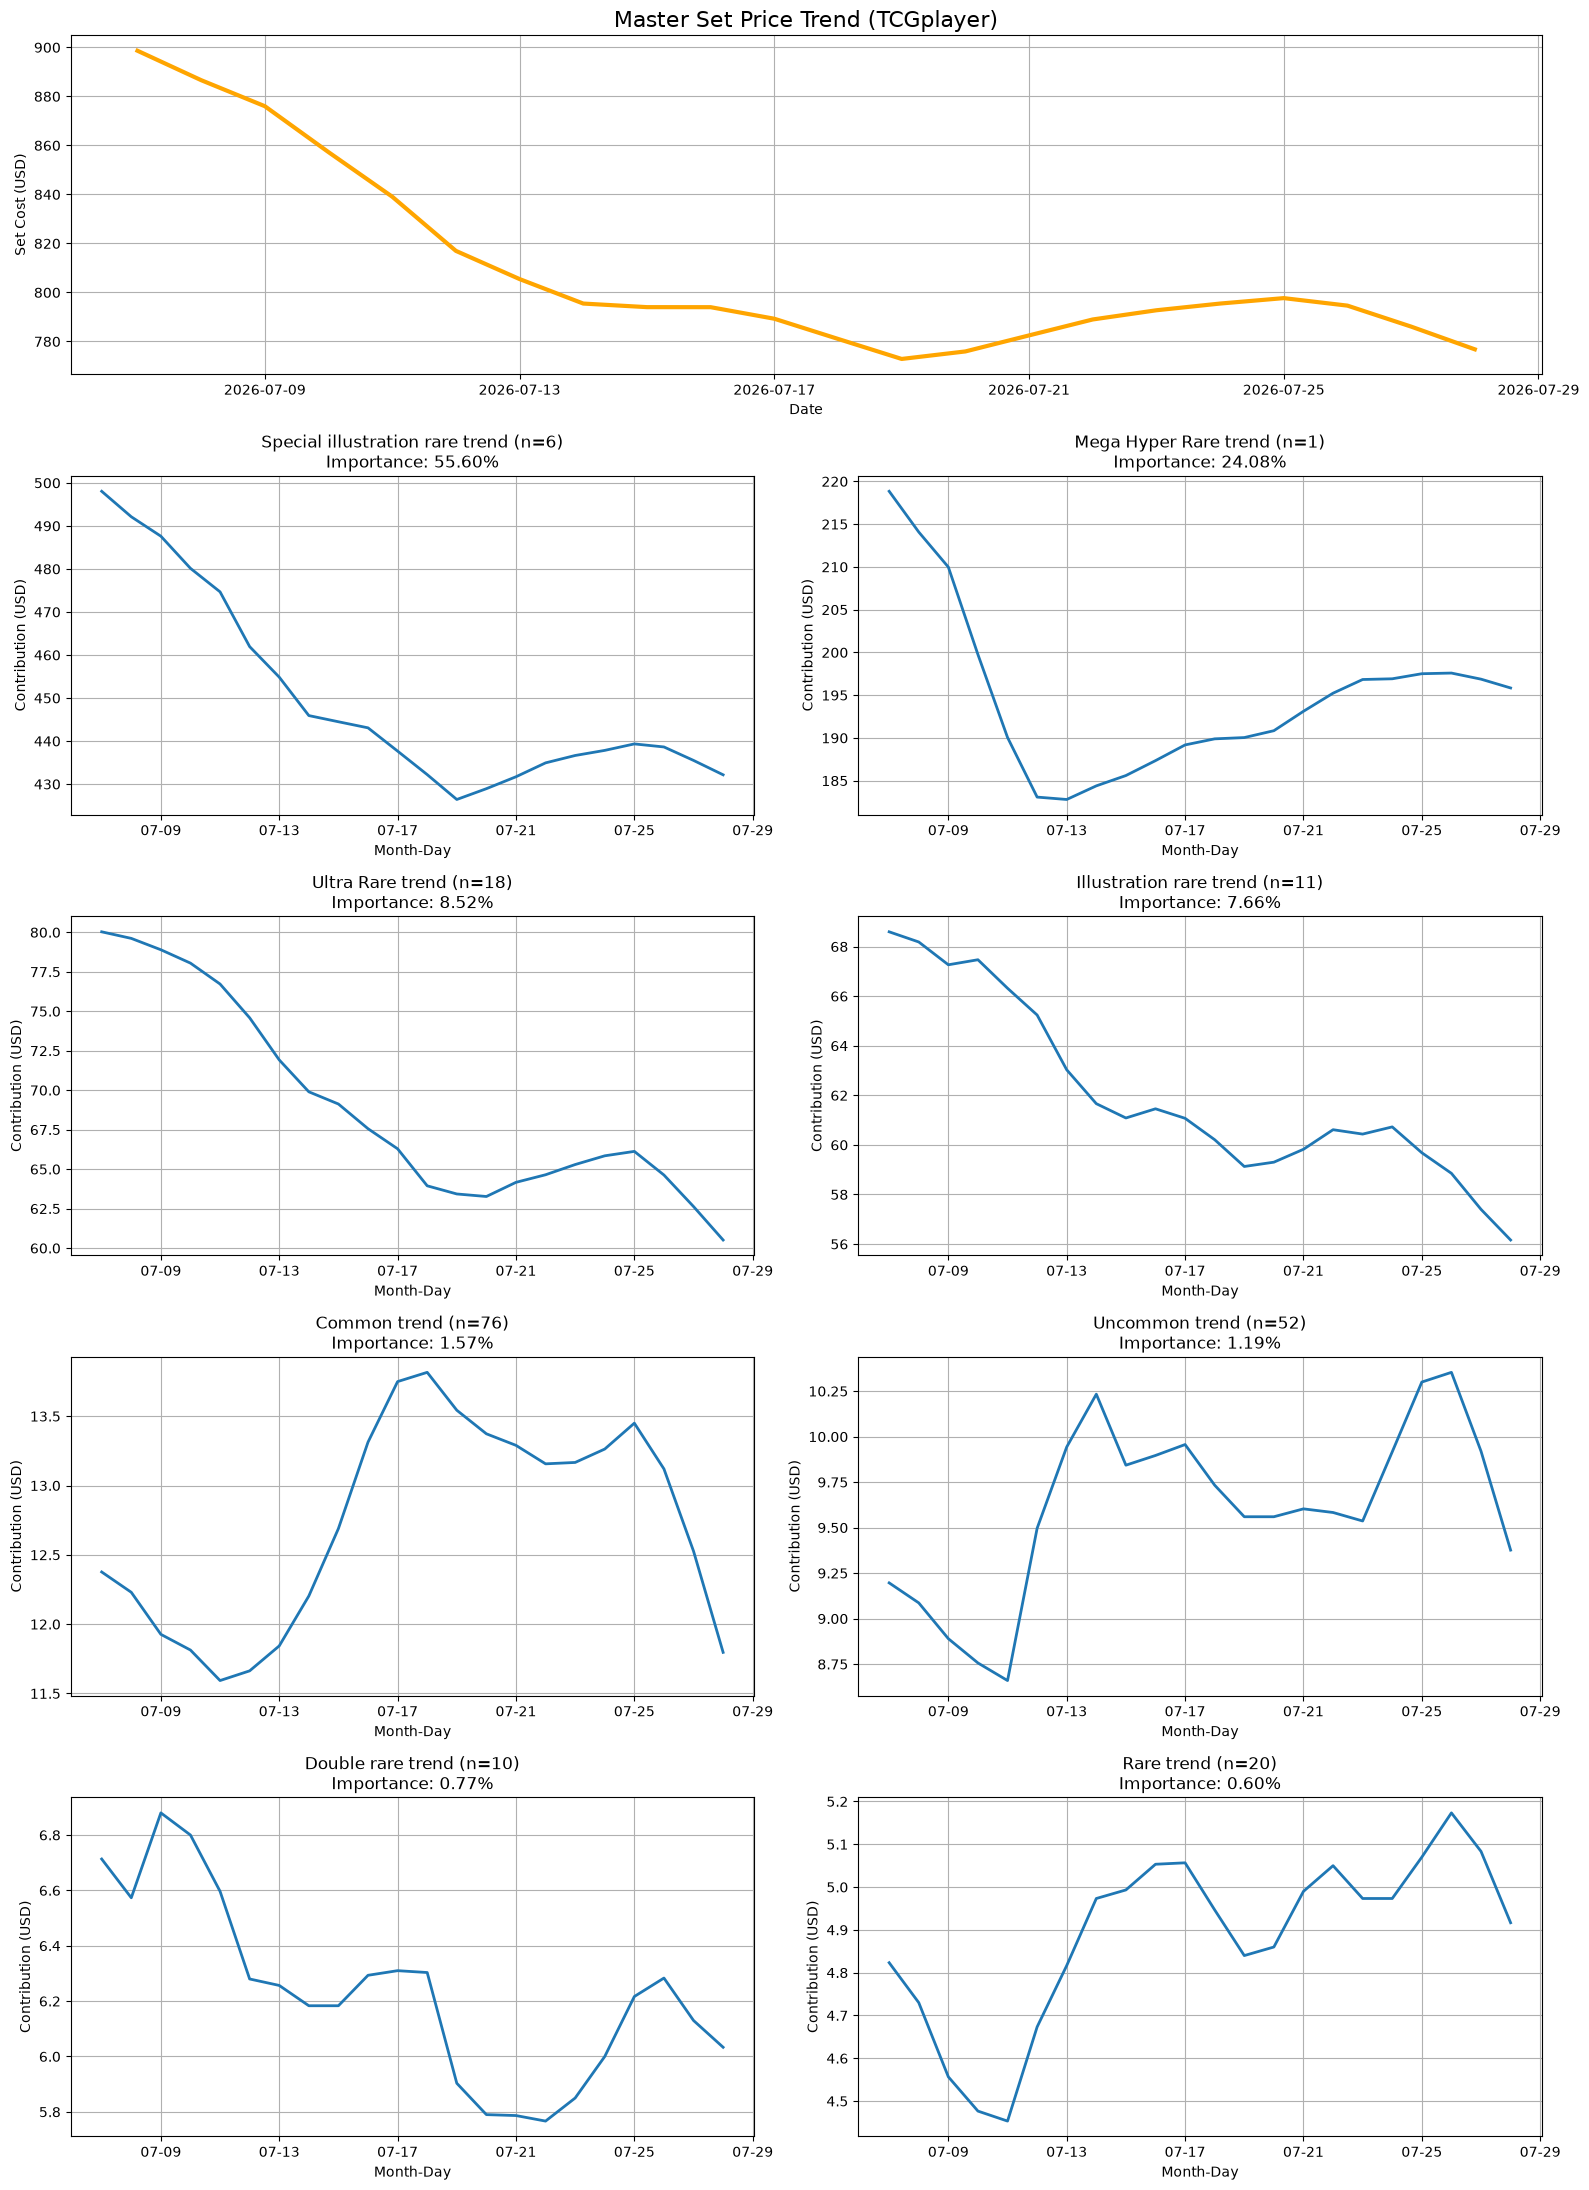

In [16]:
plot_set_and_rarity_trends("../data/chaos_rising_combined_clean.csv", source="tp", period=3)

In [ ]:
df = pd.read_csv("../data/psyduck_combined_clean.csv")

df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])

# Filter to a specific card and set index
psyduck = df[df["id"] == "me02.5-226"].set_index("snapshot_date")

# Extract the series to be forecast
ts = psyduck["tp_holofoil_marketPrice"].dropna()


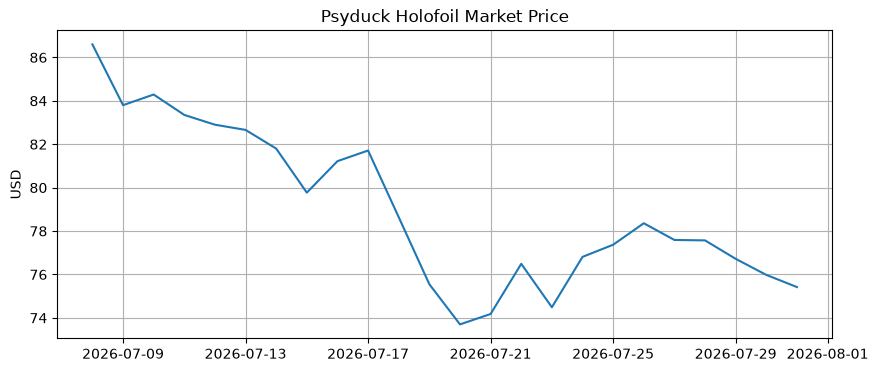

In [19]:
plt.figure(figsize=(10,4))
plt.plot(ts.index, ts.values)
plt.title("Psyduck Holofoil Market Price")
plt.ylabel("USD")
plt.grid(True)
plt.show()


In [ ]:
# Staionarity tests

# ADF p-value should be < 0.05
def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput[f"Critical Value ({key})"] = value
    print(dfoutput)

# KPSS p-value should be > 0.05
def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output[f"Critical Value ({key})"] = value
    print(kpss_output)

In [33]:
adf_test(ts)
kpss_test(ts)

Results of Dickey-Fuller Test:
Test Statistic                 -1.688746
p-value                         0.436920
#Lags Used                      2.000000
Number of Observations Used    21.000000
Critical Value (1%)            -3.788386
Critical Value (5%)            -3.013098
Critical Value (10%)           -2.646397
dtype: float64
Results of KPSS Test:
Test Statistic           0.560716
p-value                  0.027992
Lags Used                3.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


In [37]:
ts_diff = ts.diff().dropna()


In [38]:
adf_test(ts_diff)
kpss_test(ts_diff)

Results of Dickey-Fuller Test:
Test Statistic                 -4.626813
p-value                         0.000115
#Lags Used                      0.000000
Number of Observations Used    22.000000
Critical Value (1%)            -3.769733
Critical Value (5%)            -3.005426
Critical Value (10%)           -2.642501
dtype: float64
Results of KPSS Test:
Test Statistic           0.170211
p-value                  0.100000
Lags Used                0.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


/tmp/ipykernel_1368/3078923093.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")


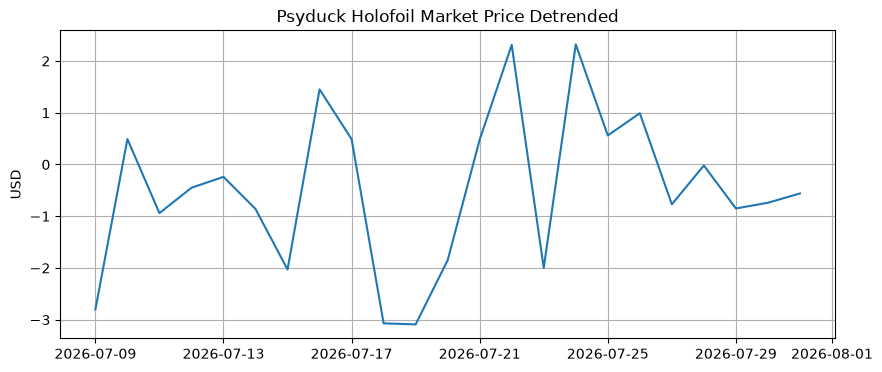

In [39]:
plt.figure(figsize=(10,4))
plt.plot(ts_diff.index, ts_diff.values)
plt.title("Psyduck Holofoil Market Price Detrended")
plt.ylabel("USD")
plt.grid(True)
plt.show()


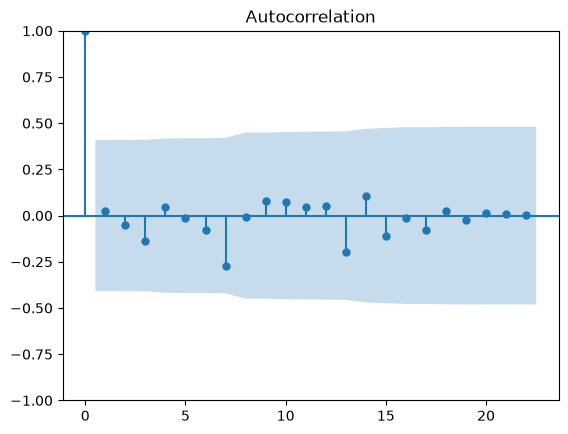

In [44]:
# plot ACF
plt.show(plot_acf(ts_diff, lags=22))

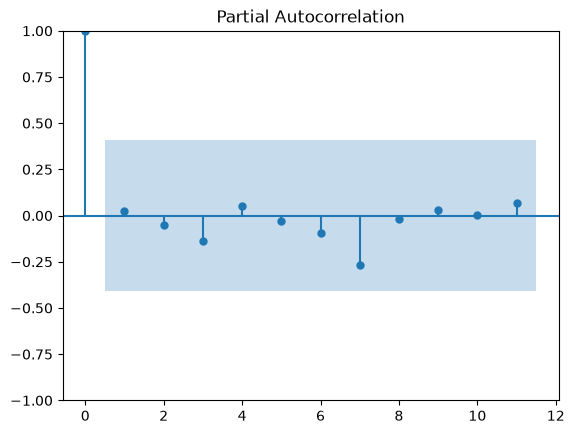

In [47]:
# plot PACF
plt.show(plot_pacf(ts_diff, lags=11))

In [40]:
# define the training %
split_index = int(len(ts) * 0.90)
# training set
train = ts.iloc[:split_index]
# validation set
val = ts.iloc[split_index:]

In [48]:
# define the model
arima = ARIMA(train, order=(1, 1, 1), trend="t")

# fit the ARIMA model
arima_fit = arima.fit()
# show model summary
print(arima_fit.summary())

                                  SARIMAX Results                                  
Dep. Variable:     tp_holofoil_marketPrice   No. Observations:                   21
Model:                      ARIMA(1, 1, 1)   Log Likelihood                 -37.845
Date:                     Fri, 31 Jul 2026   AIC                             83.690
Time:                             22:52:08   BIC                             87.673
Sample:                         07-08-2026   HQIC                            84.467
                              - 07-28-2026                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.4541      0.403     -1.125      0.260      -1.245       0.337
ar.L1         -0.1447      7.763     -0.019      0.985     -15.360      15.070
ma.L1       

/home/ucloud/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/ucloud/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/ucloud/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
# predict real GDP values (avg + confidence interval)
predictions = arima_fit.get_forecast(steps=len(val))
# get point prediction
predictions_mean = predictions.predicted_mean
# build the confidence interval
conf_int = predictions.conf_int()
# show prediction
print("Real GDP predictions:")
print("-------------------------------------")
print(predictions_mean)

Real GDP predictions:
-------------------------------------
2026-07-29    77.131647
2026-07-30    76.675280
2026-07-31    76.221522
Freq: D, Name: predicted_mean, dtype: float64


In [62]:
# trasform validation into a series
val_series = val.squeeze()
# Ensure predictions and actual values are aligned before computing metrics
predictions_mean.index = val.index

# compute MAE
mae = np.mean(np.abs(val_series - predictions_mean.values))
# compute RMSE
rmse = np.sqrt(np.mean((val_series - predictions_mean.values) ** 2))
# compute MAPE
mape = np.mean(np.abs((val_series - predictions_mean.values) / val_series)) * 100

# Print metrics
print("Forecast Accuracy Metrics")
print("-------------------------")
print(f"MAE :  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")

Forecast Accuracy Metrics
-------------------------
MAE :  0.6361
RMSE: 0.6571
MAPE: 0.84%


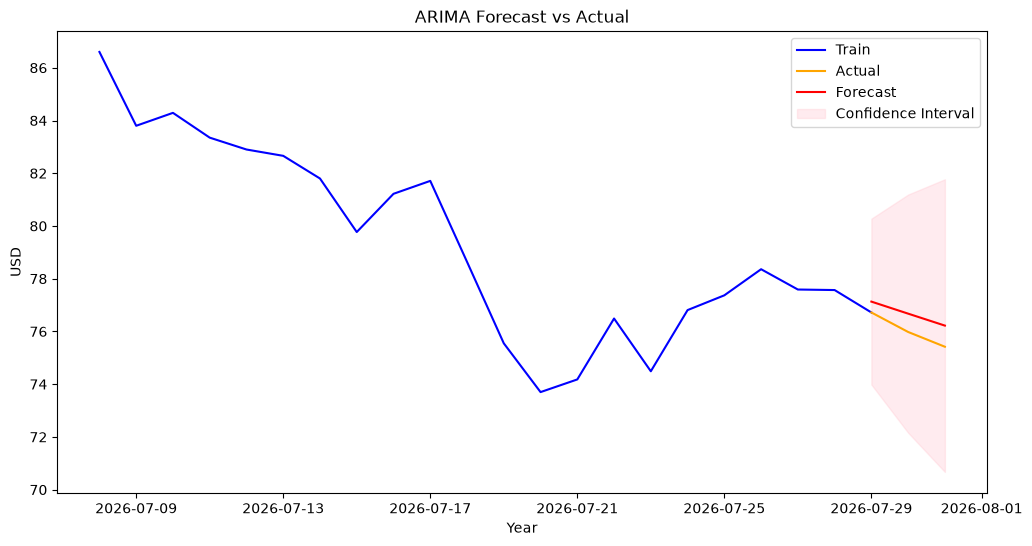

In [58]:
# Convert train to timestamp
#train_plot = train.to_timestamp()
# Convert val to timestamp
#val_plot = val.to_timestamp()

# Align the prediction series w/ validation
predictions_mean.index = val.index
# Align the CI w/ validation
conf_int.index = val.index
# keep only last 30 points
train_tail = train[-30:]
# Bridge first validation points to make plot continuous
bridge_point = val.iloc[:1]
train_tail = pd.concat([train_tail, bridge_point])

# plot
plt.figure(figsize=(12, 6))
# last 30 train points
plt.plot(train_tail, label="Train", color="blue")
# actual validation points
plt.plot(val, label="Actual", color="orange")
# forecast
plt.plot(predictions_mean, label="Forecast", color="red")
# confidence interval
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="pink",
    alpha=0.3,
    label="Confidence Interval",
)
# labels & title
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Year")
plt.ylabel("USD")
plt.legend()
plt.show()

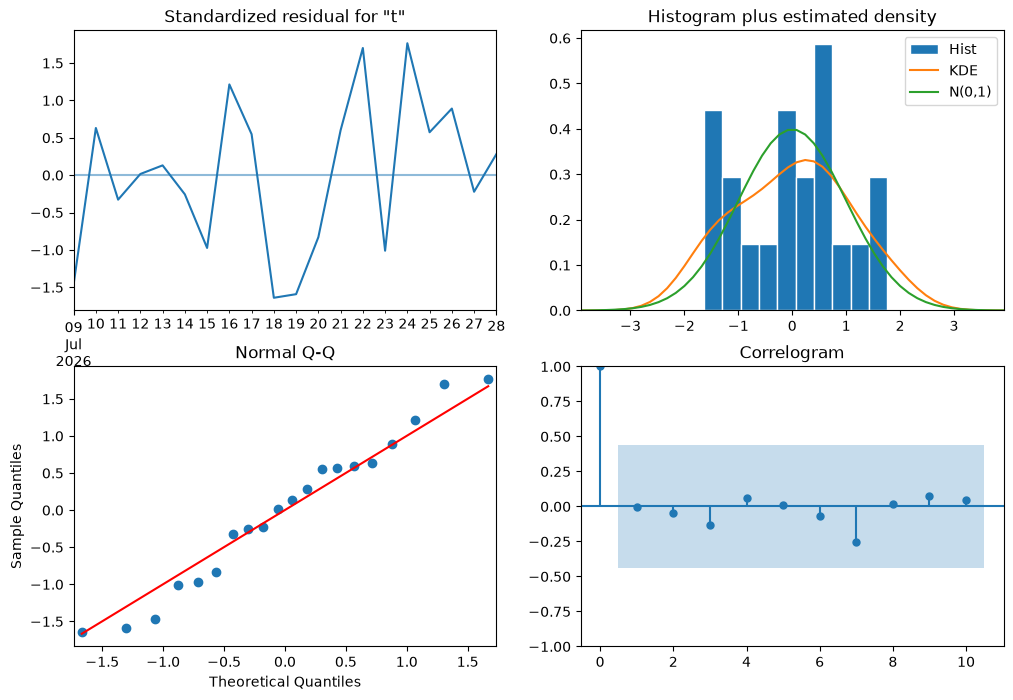

In [65]:
arima_fit.plot_diagnostics(figsize=(12,8))
plt.show()
